In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np

sns.color_palette("rocket", as_cmap=True)

%matplotlib inline

In [2]:
df = pd.read_csv("bankmarketing.csv")

df.head(3)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [4]:
df['job'].dtype

dtype('O')

In [5]:
# from sklearn.preprocessing import LabelEncoder

# columns = [col for col in df.columns if df[col].dtype not in (np.float64, np.int64)]

# print(columns)

# encoders = {}
# for col in columns:
#     encoders[col] = LabelEncoder()
#     df[col] = encoders[col].fit_transform(df[col])

# df.info()

In [6]:
df.head(3)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [7]:
for col in df.columns:
    print(f"Unique count for {col}: {len(df[col].unique())}")

Unique count for age: 78
Unique count for job: 12
Unique count for marital: 4
Unique count for education: 8
Unique count for default: 3
Unique count for housing: 3
Unique count for loan: 3
Unique count for contact: 2
Unique count for month: 10
Unique count for day_of_week: 5
Unique count for duration: 1544
Unique count for campaign: 42
Unique count for pdays: 27
Unique count for previous: 8
Unique count for poutcome: 3
Unique count for emp.var.rate: 10
Unique count for cons.price.idx: 26
Unique count for cons.conf.idx: 26
Unique count for euribor3m: 316
Unique count for nr.employed: 11
Unique count for y: 2


<Axes: xlabel='age', ylabel='Count'>

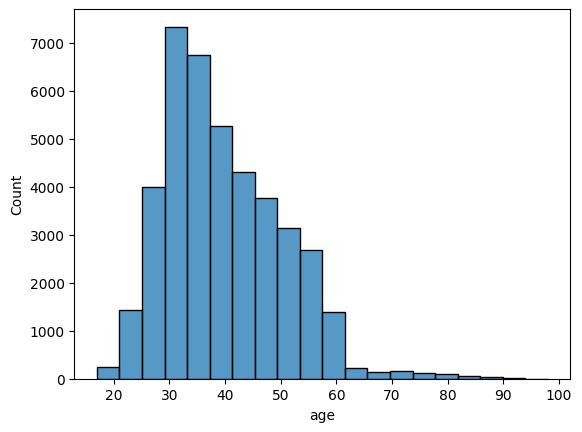

In [8]:
sns.histplot(data=df, x='age', bins=20)

11


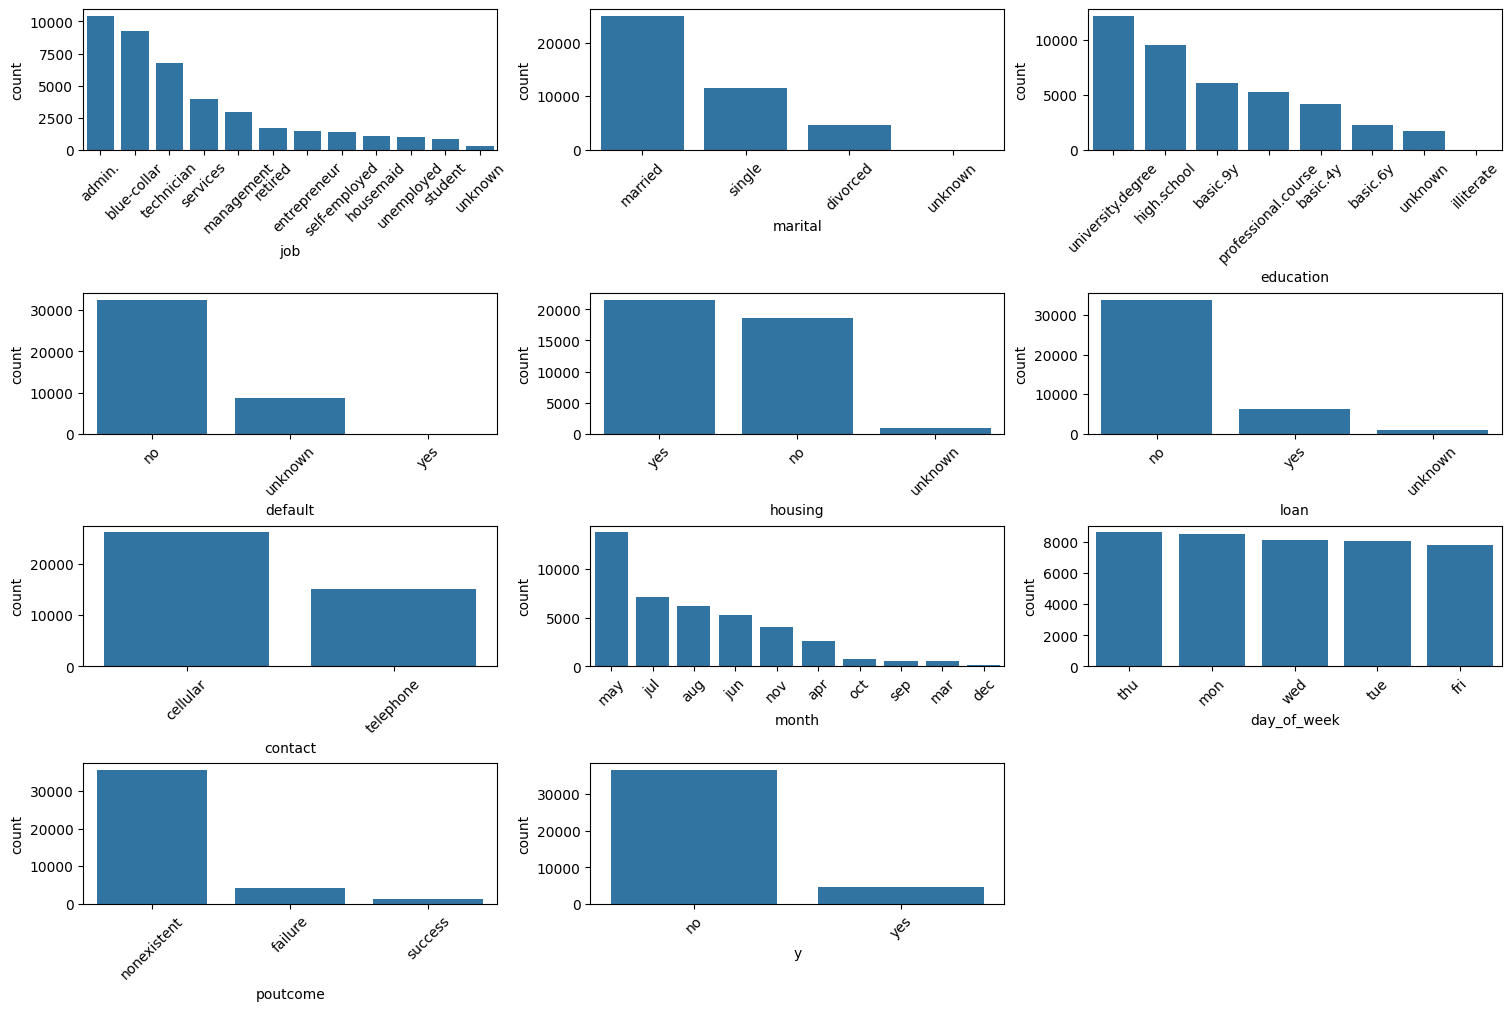

In [29]:
columns = [col for col in df.columns if df[col].dtype not in (np.float64, np.int64)]
print(len(columns))

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 10), constrained_layout=True)
axes = axes.flatten()

for idx, col in enumerate(columns):
    x = sns.countplot(data=df, x=col, order=df[col].value_counts().index, ax=axes[idx])
    axes[idx].tick_params(axis='x', labelrotation=45)

axes[len(axes) - 1].remove()
plt.show()

<Axes: >

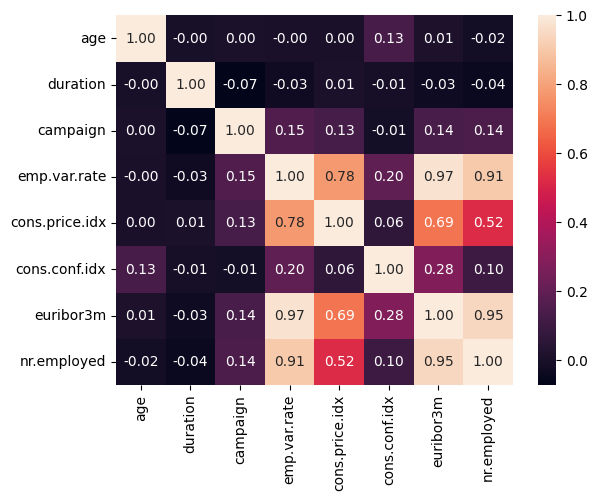

In [30]:
num = df[['age','duration','campaign','emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed']]
sns.heatmap(num.corr(), annot=True, fmt=".2f")

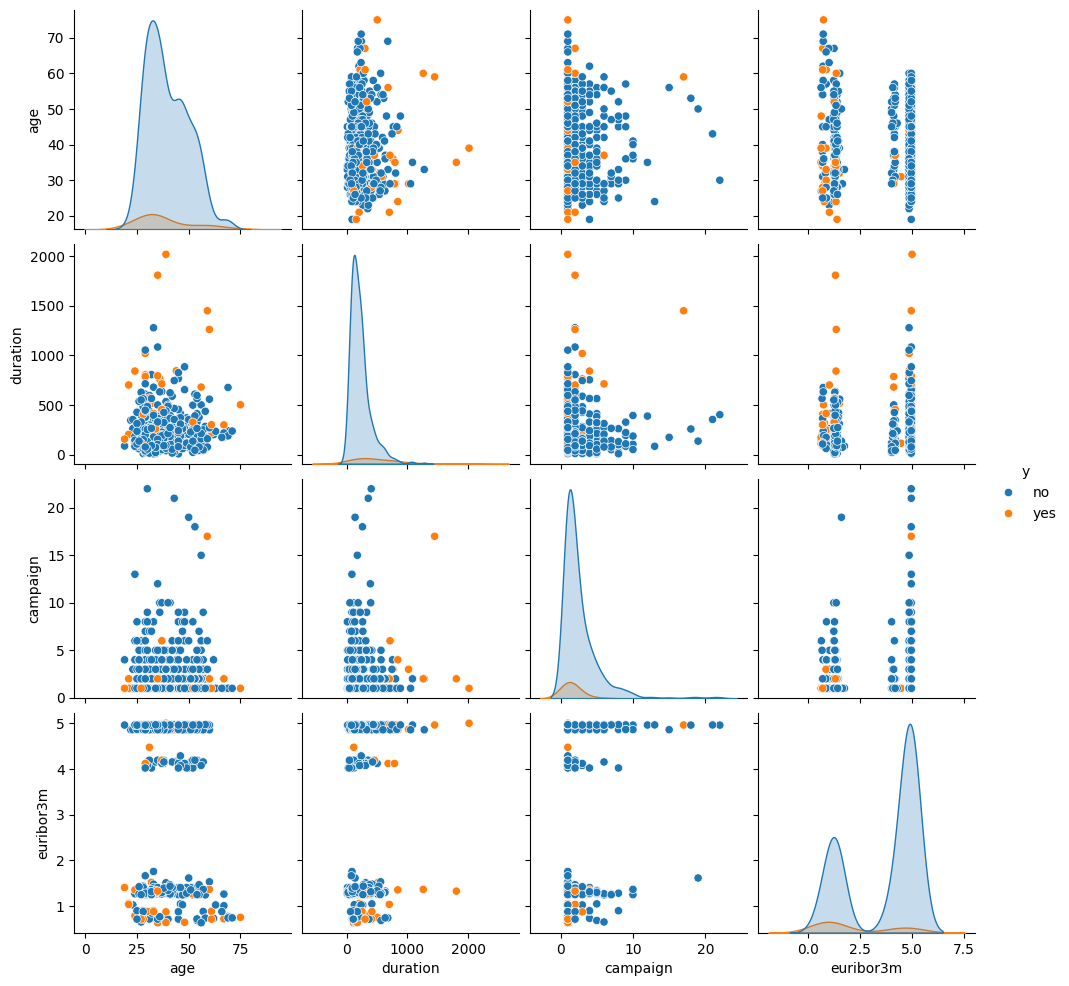

In [31]:
sns.pairplot(df.sample(500), vars=['age','duration','campaign','euribor3m'], hue='y')

<Axes: xlabel='contact', ylabel='job'>

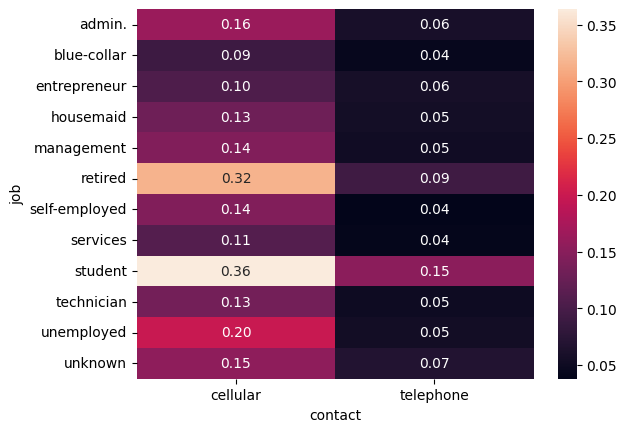

In [35]:
conv = df.groupby(['job','contact'])['y'].apply(lambda s: (s=='yes').mean()).unstack(fill_value=0)
conv.sort_values(by='telephone', ascending=False).head(10)
sns.heatmap(conv, annot=True, fmt=".2f")

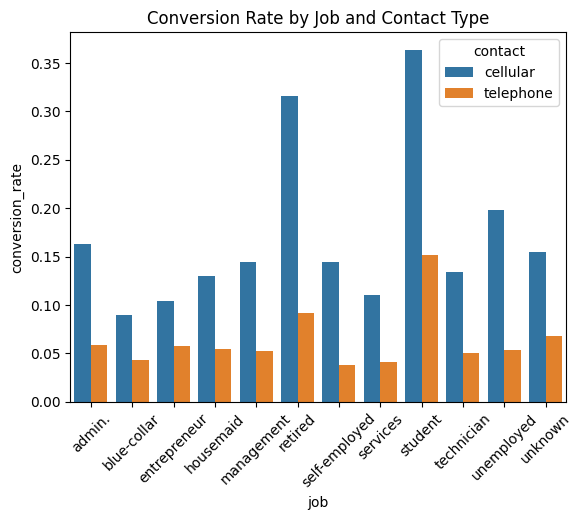

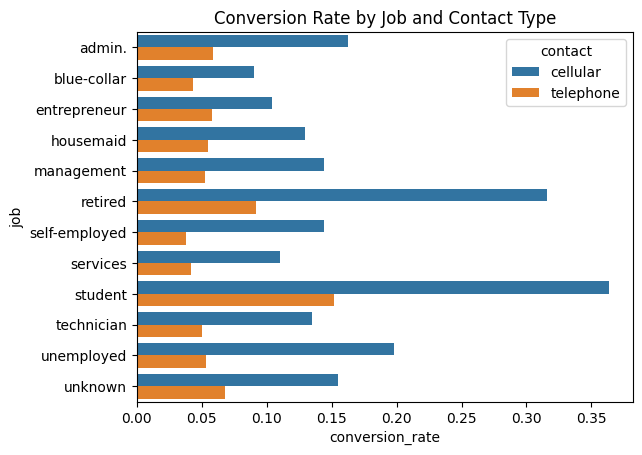

In [ ]:
conv_reset = conv.reset_index().melt(id_vars='job',
                                     var_name='contact',
                                     value_name='conversion_rate')

plt.figure()  
sns.barplot(data=conv_reset,
            y='job',
            x='conversion_rate',
            hue='contact')
plt.title("Conversion Rate by Job and Contact Type")
plt.show()